1. MODEL SCORES (80% Training Split)
Logistic Regression  Test Accuracy: 0.9667
SVM                  Test Accuracy: 0.9667
Random Forest        Test Accuracy: 0.9000
Decision Tree        Test Accuracy: 0.9333

2. CROSS-VALIDATION SCORES (6-Fold)
Logistic Regression  CV Scores: [0.9  1.   0.95 0.9  1.   1.  ]
                     Mean: 0.9583 (+/- 0.0898)

SVM                  CV Scores: [0.95 1.   0.95 0.9  1.   1.  ]
                     Mean: 0.9667 (+/- 0.0745)

Random Forest        CV Scores: [0.9  1.   0.95 0.9  1.   0.95]
                     Mean: 0.9500 (+/- 0.0816)

Decision Tree        CV Scores: [0.95 1.   0.95 0.9  1.   0.9 ]
                     Mean: 0.9500 (+/- 0.0816)

Best model (by CV): SVM with mean accuracy 0.9667


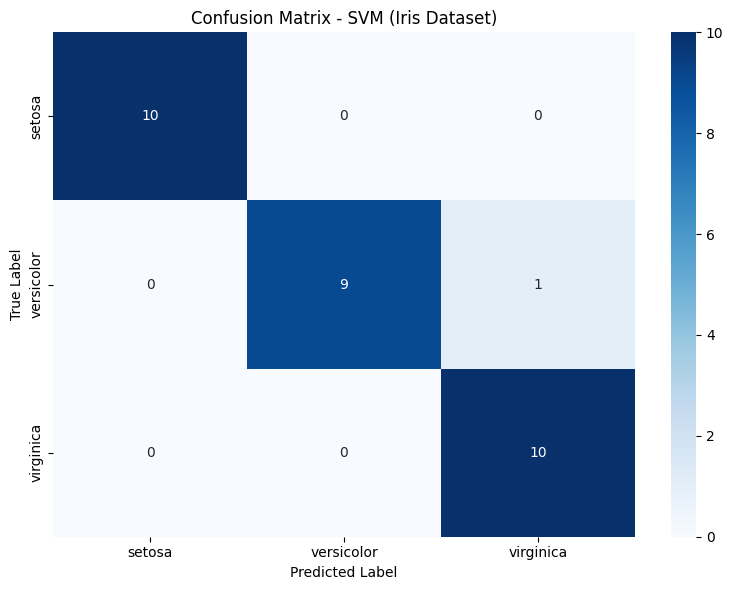

In [1]:
# ==============================================
# RESIT 2023 - QUESTION 1
# Iris Dataset - 80% Training Split
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# 1. Train and get scores (5 Marks)
print("="*60)
print("1. MODEL SCORES (80% Training Split)")
print("="*60)
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name:20s} Test Accuracy: {score:.4f}")

# 2. Cross-validation with 6 folds (10 Marks)
print("\n" + "="*60)
print("2. CROSS-VALIDATION SCORES (6-Fold)")
print("="*60)
best_model = None
best_mean_score = 0
best_name = ""

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=6, scoring='accuracy')
    mean_score = cv_scores.mean()
    print(f"{name:20s} CV Scores: {cv_scores}")
    print(f"{'':20s} Mean: {mean_score:.4f} (+/- {cv_scores.std()*2:.4f})\n")
    
    if mean_score > best_mean_score:
        best_mean_score = mean_score
        best_model = model
        best_name = name

print(f"Best model (by CV): {best_name} with mean accuracy {best_mean_score:.4f}")

# 3. Plot confusion matrix for best model (10 Marks)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f'Confusion Matrix - {best_name} (Iris Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================
# RESIT 2023 - QUESTION 2a
# Facemesh with MediaPipe
# ==============================================

import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe FaceMesh
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# FaceMesh configuration
face_mesh = mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

def process_facemesh_image(image_path):
    """Apply FaceMesh on a single image"""
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Could not load image")
        return
    
    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process
    results = face_mesh.process(image_rgb)
    
    # Draw landmarks
    annotated_image = image.copy()
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles
                .get_default_face_mesh_tesselation_style()
            )
    
    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.title('FaceMesh Landmarks')
    plt.axis('off')
    plt.show()

def process_facemesh_webcam():
    """Real-time FaceMesh using webcam"""
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not access webcam")
        return
    
    print("Press 'q' to quit")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Flip horizontally for selfie view
        frame = cv2.flip(frame, 1)
        
        # Convert to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(frame_rgb)
        
        # Draw landmarks
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                mp_drawing.draw_landmarks(
                    image=frame,
                    landmark_list=face_landmarks,
                    connections=mp_face_mesh.FACEMESH_TESSELATION,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_drawing_styles
                    .get_default_face_mesh_tesselation_style()
                )
        
        cv2.imshow('FaceMesh', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [3]:
# ==============================================
# RESIT 2023 - QUESTION 2b
# Pose Detection with MediaPipe
# ==============================================

import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

def pose_detection_webcam():
    """Real-time pose detection using webcam"""
    pose = mp_pose.Pose(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    
    cap = cv2.VideoCapture(0)
    
    print("Press 'q' to quit")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        frame = cv2.flip(frame, 1)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)
        
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                frame,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style()
            )
        
        cv2.imshow('Pose Detection', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

AttributeError: module 'mediapipe' has no attribute 'solutions'

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7818 - loss: 0.6052 - val_accuracy: 0.8610 - val_loss: 0.3794
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.8614 - loss: 0.3850 - val_accuracy: 0.8809 - val_loss: 0.3212
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8819 - loss: 0.3304 - val_accuracy: 0.8928 - val_loss: 0.2919
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8935 - loss: 0.2962 - val_accuracy: 0.8910 - val_loss: 0.2899
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9042 - loss: 0.2706 - val_accuracy: 0.9012 - val_loss: 0.2675
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9102 - loss: 0.2497 - val_accuracy: 0.9068 - val_loss: 0.2626
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9162 - loss: 0.2286 - val_accuracy: 0.9086 - val_loss: 0.2576
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9192 -

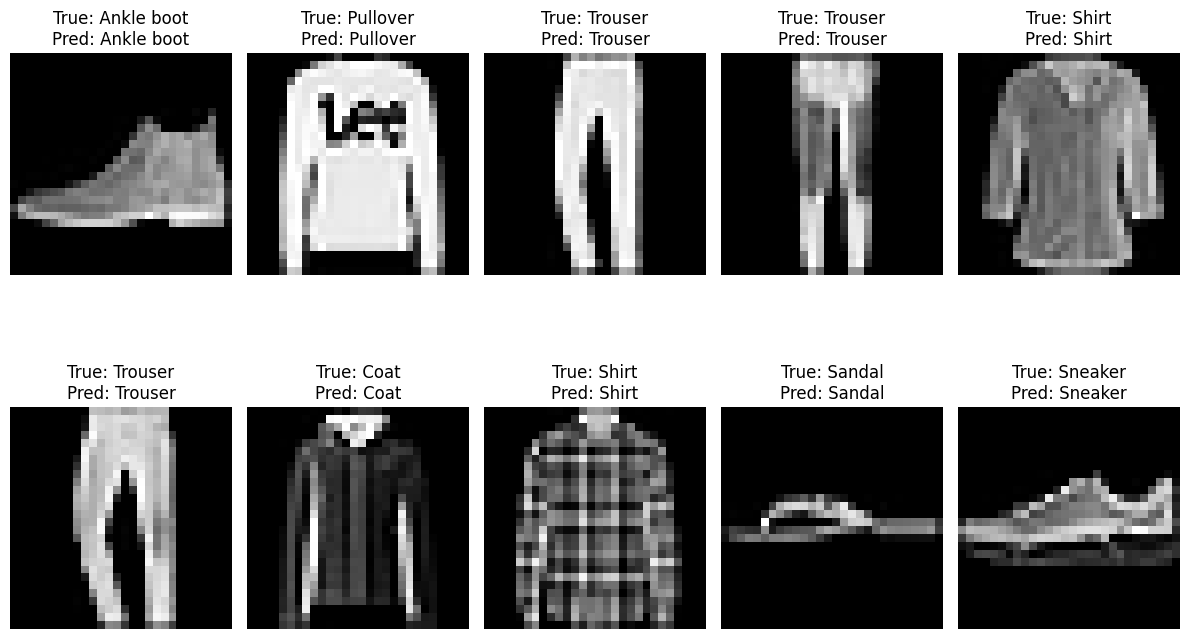

In [4]:
# ==============================================
# RESIT 2023 - QUESTION 2c
# Image Classification with Fashion MNIST
# ==============================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Build CNN model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', 
                        input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

# Train
history = model.fit(
    X_train.reshape(-1, 28, 28, 1), y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test.reshape(-1, 28, 28, 1), y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Predict and visualize
predictions = model.predict(X_test.reshape(-1, 28, 28, 1))
pred_labels = np.argmax(predictions, axis=1)

# Show some results
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'True: {class_names[y_test[i]]}\nPred: {class_names[pred_labels[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()